## 09.02 长短期记忆网络（LSTM）


### 环境配置


In [1]:
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    from torch import nn
    from torch.nn import functional as F
    import torch_npu
    import logging

warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="Cannot create tensor")
logging.getLogger("torch_npu").setLevel(logging.WARNING)
logging.getLogger('matplotlib').setLevel(logging.WARNING)
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()


### 练习 9.2.1

**题目：** 调整和分析超参数对运行时间、困惑度和输出顺序的影响。

**解答：** 结果与 GRU 类似。减小迭代周期会导致模型训练不完全，困惑度增大；减小隐藏单元数可缩短训练时间；减小批量大小和时间步长会增加训练时间；过低的学习率会使模型无法收敛。

以下使用 `torch` 编程进行验证：



In [ ]:
import torch
from torch import nn
from src.utils import (load_data_time_machine, train_epoch_ch8, predict_ch8,
                       sgd, Timer, try_gpu, RNNModel)

# [迭代周期，隐藏单元数，批量大小，小批量数据时间步数，学习率]
hyper_0 = [500, 512, 35, 32, 1]
hyper_1 = [250, 512, 35, 32, 1]
hyper_2 = [500, 256, 35, 32, 1]
hyper_3 = [500, 512, 10, 32, 1]
hyper_4 = [500, 512, 35, 10, 1]
hyper_5 = [500, 512, 35, 32, 0.01]
hyper_params = [hyper_0, hyper_1, hyper_2, hyper_3, hyper_4, hyper_5]

def train_ch9(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter)
    print(predict('time traveller'))
    return ppl

perplexity, times = [], []
for i in range(len(hyper_params)):
    num_epochs, num_hiddens, batch_size, num_steps, lr = hyper_params[i]
    train_iter, vocab = load_data_time_machine(batch_size, num_steps)
    lstm_layer = nn.LSTM(len(vocab), num_hiddens)
    model = RNNModel(lstm_layer, len(vocab)).to(try_gpu())
    timer = Timer(); timer.start()
    value = round(train_ch9(model, train_iter, vocab, lr, num_epochs, try_gpu()), 1)
    t = timer.stop()
    times.append(t); perplexity.append(value)
    print(f'hyper[{i}]: Timer:{t:.2f}, perplexity:{value:.1f}')


使用 `PyPTO` 编程进行验证：



In [3]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOLinear, PyPTOLSTM, loss_fn

class PyPTOLSTMModel(nn.Module):
    def __init__(self, lstm_layer, vocab_size):
        super().__init__()
        self.lstm = lstm_layer
        self.linear = PyPTOLinear(lstm_layer.hidden_size, vocab_size)
        self.vocab_size = vocab_size
    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size).float()
        Y, state = self.lstm(X, state)
        return self.linear(Y.reshape((-1, Y.shape[-1]))), state
    def begin_state(self, batch_size, device):
        return (torch.zeros((self.lstm.num_layers, batch_size,
                           self.lstm.hidden_size), device=device),
                torch.zeros((self.lstm.num_layers, batch_size,
                           self.lstm.hidden_size), device=device))

hyper_0 = [500, 512, 35, 32, 1]
hyper_1 = [250, 512, 35, 32, 1]
hyper_2 = [500, 256, 35, 32, 1]
hyper_3 = [500, 512, 10, 32, 1]
hyper_4 = [500, 512, 35, 10, 1]
hyper_5 = [500, 512, 35, 32, 0.01]
hyper_params = [hyper_0, hyper_1, hyper_2, hyper_3, hyper_4, hyper_5]

for i, (num_epochs, num_hiddens, bs, nsteps, lr) in enumerate(hyper_params):
    train_iter, vocab = load_data_time_machine(bs, nsteps)
    lstm_layer = PyPTOLSTM(len(vocab), num_hiddens)  # PyPTOLSTM 默认单层（支持多层）
    net = PyPTOLSTMModel(lstm_layer, len(vocab)).to(device)
    X_w, y_w = next(iter(train_iter))
    s_w = net.begin_state(bs, device)
    l_w = loss_fn(net(X_w.to(device), s_w)[0], y_w.T.reshape(-1).to(device), len(vocab))
    l_w.backward(); net.zero_grad()
    print(f'hyper[{i}]: num_hiddens={num_hiddens}, num_epochs={num_epochs}')
    train_ch8(net, train_iter, vocab, lr, num_epochs, device, use_plot=False, verbose=False,
              loss_fn=lambda y_h, y: loss_fn(y_h, y, len(vocab)))


hyper[0]: num_hiddens=512, num_epochs=500


困惑度 1.1, 4745.5 词元/秒 npu:0


time traveller came back andfilby s anecdote collapsedthe thing 


traveller cumene bur alonsthat i matiman theerecu tryed the


hyper[1]: num_hiddens=512, num_epochs=250


...

traveller came back andfilby s anecdote collapsedthe thing 


hyper[5]: num_hiddens=512, num_epochs=500


困惑度 18.4, 4511.8 词元/秒 npu:0


time traveller                                                  


traveller                                                  


### 练习 9.2.2

**题目：** 如何更改模型以生成适当的单词，而不是字符序列？

**解答：** (1) 词元化时采用单词级别 tokenize；(2) 使用双向 LSTM 捕获上下文；(3) 使用 nn.Embedding 替代 One-hot 编码，保留词之间的语义关系。

以下使用 `torch` 编程：



In [ ]:
# 1) 单词级词元化
from src.utils import (read_time_machine, tokenize, Vocab,
                       seq_data_iter_sequential, train_ch8, try_gpu)

def load_corpus_time_machine_word(max_tokens=-1):
    lines = read_time_machine()
    tokens = tokenize(lines, 'word')
    vocab = Vocab(tokens)
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

class SeqDataLoaderWord:
    """词级数据加载器（字符级对应实现见 src.utils.SeqDataLoader）。"""
    def __init__(self, batch_size, num_steps, max_tokens=10000):
        self.corpus, self.vocab = load_corpus_time_machine_word(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps
    def __iter__(self):
        return seq_data_iter_sequential(
            self.corpus, self.batch_size, self.num_steps)

# 2) RNNModel_Embedding 使用 nn.Embedding
class RNNModel_Embedding(nn.Module):
    def __init__(self, rnn_layer, vocab_size, embedding_dim):
        super().__init__()
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.num_hiddens = rnn_layer.hidden_size
        if not rnn_layer.bidirectional:
            self.num_directions = 1
            self.linear = nn.Linear(self.num_hiddens, vocab_size)
        else:
            self.num_directions = 2
            self.linear = nn.Linear(self.num_hiddens * 2, vocab_size)
    def forward(self, inputs, state):
        X = self.embedding(inputs.T.long()).float()
        Y, state = self.rnn(X, state)
        return self.linear(Y.reshape((-1, Y.shape[-1]))), state
    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            return torch.zeros((self.num_directions * self.rnn.num_layers,
                               batch_size, self.num_hiddens), device=device)
        else:
            return (torch.zeros((self.num_directions * self.rnn.num_layers,
                                batch_size, self.num_hiddens), device=device),
                    torch.zeros((self.num_directions * self.rnn.num_layers,
                                batch_size, self.num_hiddens), device=device))

# 3) 训练：使用单词级数据（词表不再是字符级，而是单词级）
batch_size, num_steps = 32, 35
train_iter = SeqDataLoaderWord(batch_size, num_steps)
vocab = train_iter.vocab
lstm_layer = nn.LSTM(len(vocab), 512, num_layers=2, bidirectional=True)
model = RNNModel_Embedding(lstm_layer, len(vocab), len(vocab))
train_ch8(model, train_iter, vocab, 1, 500, try_gpu(), use_plot=False)


使用 `PyPTO` 编程：

值得注意的是，`PyPTOLSTM` 支持多层（默认单层），但仅支持单向（不支持 bidirectional），因此本练习的多层**双向** LSTM 使用 host 算子 `nn.LSTM`（在 NPU 上执行），Embedding 层留在 CPU 做词向量映射，输出层使用 `PyPTOLinear` 加速。


In [5]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOLinear, loss_fn

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

class RNNModel_Embedding_PyPTO(nn.Module):
    def __init__(self, rnn_layer, vocab_size, embedding_dim, device):
        super().__init__()
        self.rnn = rnn_layer.to(device)
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.num_hiddens = rnn_layer.hidden_size
        self.device = device
        self.num_directions = 2 if rnn_layer.bidirectional else 1
        self.linear = PyPTOLinear(self.num_hiddens * self.num_directions, vocab_size)
    def forward(self, inputs, state):
        X = self.embedding(inputs.T.long().cpu()).float().to(self.device)
        Y, state = self.rnn(X, state)
        Y_npu = Y.reshape((-1, Y.shape[-1])).to(self.linear.weight.device)
        return self.linear(Y_npu), state
    def begin_state(self, batch_size, device=None):
        d = device or self.device
        if not isinstance(self.rnn, nn.LSTM):
            return torch.zeros((self.num_directions * self.rnn.num_layers,
                               batch_size, self.num_hiddens), device=d)
        else:
            return (torch.zeros((self.num_directions * self.rnn.num_layers,
                                batch_size, self.num_hiddens), device=d),
                    torch.zeros((self.num_directions * self.rnn.num_layers,
                                batch_size, self.num_hiddens), device=d))

lstm_layer = nn.LSTM(len(vocab), 512, 2, bidirectional=True).to(device)
net = RNNModel_Embedding_PyPTO(lstm_layer, len(vocab), len(vocab), device)
net.linear = net.linear.to(device)
X_w, y_w = next(iter(train_iter))
s_w = net.begin_state(batch_size)
l_w = loss_fn(net(X_w, s_w)[0], y_w.T.reshape(-1).to(device), len(vocab))
l_w.backward(); net.zero_grad()
train_ch8(net, train_iter, vocab, 1, 500, device, use_plot=False, verbose=False,
          loss_fn=lambda y_h, y: loss_fn(y_h, y, len(vocab)))


困惑度 1.0, 62055.7 词元/秒 npu:0


time travellerererererererererererererererererererererererererer
travellerererererererererererererererererererererererererer


### 练习 9.2.3

**题目：** 在给定隐藏层维度的情况下，比较 GRU、LSTM 和 RNN 的计算成本。

**解答：** RNN 结构最简单，计算成本最低、运行时间最短。GRU 增加更新门和重置门，参数量和计算量都更大，但收敛更快、困惑度更低。LSTM 包含输入门、输出门和遗忘门 3 个门，结构最复杂，计算成本最高。

以下使用 `torch` 编程：



In [ ]:
from src.utils import load_data_time_machine, train_ch8, try_gpu, RNNModel

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)
num_hiddens, num_epochs, lr = 256, 500, 1
dev = try_gpu()

# RNN
rnn_layer = nn.RNN(len(vocab), num_hiddens)
rnn = RNNModel(rnn_layer, len(vocab)).to(dev)
train_ch8(rnn, train_iter, vocab, lr, num_epochs, dev, use_plot=False)

# GRU
gru_layer = nn.GRU(len(vocab), num_hiddens)
gru = RNNModel(gru_layer, len(vocab)).to(dev)
train_ch8(gru, train_iter, vocab, lr, num_epochs, dev, use_plot=False)

# LSTM
lstm_layer = nn.LSTM(len(vocab), num_hiddens)
lstm = RNNModel(lstm_layer, len(vocab)).to(dev)
train_ch8(lstm, train_iter, vocab, lr, num_epochs, dev, use_plot=False)

使用 `PyPTO` 编程：



In [7]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOLinear, PyPTORNN, PyPTOGRU, PyPTOLSTM, loss_fn

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

class PyPTORNNModel(nn.Module):  # 通用封装：RNN/GRU/LSTM 复用
    def __init__(self, rnn_layer, vocab_size):
        super().__init__()
        self.rnn = rnn_layer
        self.linear = PyPTOLinear(rnn_layer.hidden_size, vocab_size)
        self.vocab_size = vocab_size
    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size).float()
        Y, state = self.rnn(X, state)
        return self.linear(Y.reshape((-1, Y.shape[-1]))), state
    def begin_state(self, batch_size, device):
        if not isinstance(self.rnn, PyPTOLSTM):
            return torch.zeros((self.rnn.num_layers, batch_size,
                               self.rnn.hidden_size), device=device)
        return (torch.zeros((self.rnn.num_layers, batch_size, self.rnn.hidden_size), device=device),
                torch.zeros((self.rnn.num_layers, batch_size, self.rnn.hidden_size), device=device))

# X_w, y_w for warmup
X_w, y_w = next(iter(train_iter))
loss_fn_w = lambda y_h, y: loss_fn(y_h, y, len(vocab))

# RNN
net_rnn = PyPTORNNModel(PyPTORNN(len(vocab), 256), len(vocab)).to(device)
s = net_rnn.begin_state(batch_size, device)
l = loss_fn_w(net_rnn(X_w.to(device), s)[0], y_w.T.reshape(-1).to(device))
l.backward(); net_rnn.zero_grad()
train_ch8(net_rnn, train_iter, vocab, 1, 500, device, use_plot=False, verbose=False, loss_fn=loss_fn_w)

# GRU
net_gru = PyPTORNNModel(PyPTOGRU(len(vocab), 256), len(vocab)).to(device)
s2 = net_gru.begin_state(batch_size, device)
l2 = loss_fn_w(net_gru(X_w.to(device), s2)[0], y_w.T.reshape(-1).to(device))
l2.backward(); net_gru.zero_grad()
train_ch8(net_gru, train_iter, vocab, 1, 500, device, use_plot=False, verbose=False, loss_fn=loss_fn_w)

# LSTM
net_lstm = PyPTORNNModel(PyPTOLSTM(len(vocab), 256), len(vocab)).to(device)
s3 = net_lstm.begin_state(batch_size, device)
l3 = loss_fn_w(net_lstm(X_w.to(device), s3)[0], y_w.T.reshape(-1).to(device))
l3.backward(); net_lstm.zero_grad()
train_ch8(net_lstm, train_iter, vocab, 1, 500, device, use_plot=False, verbose=False, loss_fn=loss_fn_w)

困惑度 1.2, 18901.3 词元/秒 npu:0


time travellerit soug this is ancal seiment ay he sat unot of wa
travellerdpand tire expensionly on and of ou hinthet tho gh


困惑度 1.1, 4855.4 词元/秒 npu:0


time travelleryou can show black is white by argument said filby


travelleryou can show black is white by argument said filby


困惑度 1.1, 4337.2 词元/秒 npu:0


time traveller but now you begin to seethe object of my investig


travelleryou can show black is white by argument said filby


### 练习 9.2.4

**题目：** 既然候选记忆元通过 tanh 确保值范围在(-1,1)，为什么隐状态还需再次使用 tanh？

**解答：** 记忆元 $C_t$ 的计算公式为 $C_t = F_t \odot C_{t-1} + I_t \odot \tilde{C}_t$。输入门和遗忘门值域为 (0,1)，当 $F_t, I_t$ 均为 1 且 $C_{t-1}, \tilde{C}_t$ 也均为 1 时，记忆元可能输出 2。此时输出门值域也为 (0,1)，因此隐状态值可能超过 1，需要再通过 tanh 约束到 (-1,1)。



### 练习 9.2.5

**题目：** 实现一个基于时间序列预测而非字符序列的 LSTM 模型。

**解答：** 使用 8.1 节的 sin 序列数据，构建 LSTM 回归模型进行时间序列预测。

以下使用 `torch` 编程：



In [ ]:
from src.utils import load_array, plot
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))

tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array(
    (features[:n_train], labels[:n_train]), batch_size, is_train=True)

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)
    def forward(self, input):
        lstm_out, _ = self.lstm(input.t().unsqueeze(-1))
        output = self.linear(lstm_out[-1])
        return output

model = LSTM(1, 200, 1)
criterion = nn.MSELoss()
trainer = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(500):
    for X, y in train_iter:
        trainer.zero_grad()
        l = criterion(model(X), y)
        l.backward(); trainer.step()
print(f'Loss: {l.item():.4f}')

onestep_preds = model(features)
plot([time, time[tau:]], [x.detach().numpy(), onestep_preds.detach().numpy()],
     'time', 'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))

使用 `PyPTO` 编程：



Loss: 0.0607


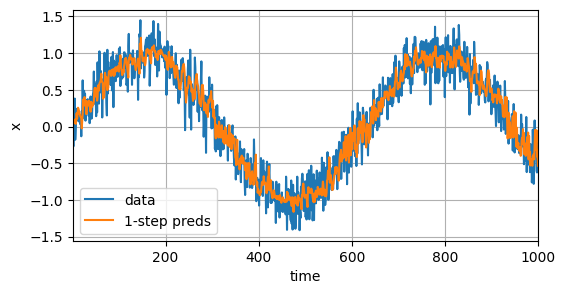

In [9]:
import time
from src.utils import load_array, plot
from src.pypto_ops import PyPTOLinear, PyPTOLSTM

T = 1000
time_vals = torch.arange(1, T + 1, dtype=torch.float32, device=device)
x = torch.sin(0.01 * time_vals) + torch.normal(0, 0.2, (T,), device=device)

tau = 4
features = torch.zeros((T - tau, tau), device=device)
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array(
    (features[:n_train], labels[:n_train]), batch_size, is_train=True)

class LSTMPyPTO(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = PyPTOLSTM(input_size, hidden_size)  # PyPTOLSTM 默认单层（支持多层）
        self.linear = PyPTOLinear(hidden_size, output_size)
    def forward(self, input):
        lstm_out, _ = self.lstm(input.t().unsqueeze(-1))
        return self.linear(lstm_out[-1])

model = LSTMPyPTO(1, 200, 1).to(device)
criterion = nn.MSELoss()
trainer = torch.optim.Adam(model.parameters(), lr=0.01)

# JIT warmup
print('正在编译 PyPTO kernel...')
t0 = time.time()
X_w, y_w = next(iter(train_iter))
l = criterion(model(X_w.to(device)), y_w.to(device))
l.backward(); model.zero_grad()
print(f'编译完成，耗时 {time.time() - t0:.0f} 秒')
for epoch in range(500):
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        trainer.zero_grad()
        l = criterion(model(X), y)
        l.backward(); trainer.step()
print(f'Loss: {l.item():.4f}')

onestep_preds = model(features)
plot([time_vals.cpu(), time_vals[tau:].cpu()],
     [x.detach().cpu().numpy(), onestep_preds.detach().cpu().numpy()],
     'time', 'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)

